Здесь будем строить ЭФР и гистрограммы для данных из дескриптора. 
При построении будем делить данные на различные классы, чтобы проанализировать распределения в зависимости от различных классов. В этой работе я решил проанализировать такие группировки:
1. Рынок (первичка, вторичка)
1. Тип квартиры (квартира, студия)
2. Гео. Для выполнения этой группировки я разбил все точки на 6 классов по терриореальному расположению. Классы выбраны рандомные, без какого-либо обсонования. Визуализация расположения расположения расположена в ячейке `[7]`.

Для начала я решил построить ЭФР для двух столбцов - площадь (area), этаж квартиры (floor).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
df_clusters = pd.read_parquet("../data/geocoding/geocodes_checkpoint.parquet")

print(df_clusters["latitude"].isna().mean() * 100, "%")

# Получил 77 процентов пропусков, поэтому геокодирование пока опустим

76.91090014663874 %


In [3]:
df = pd.read_parquet("../data/processed/v3/housing_residential_processed.parquet")
data = df.copy()

print(df.columns)
print(f"Всего записей: {len(df)}")

df_clean = df.dropna(subset=["longitude", "latitude"]).copy()

Index(['address', 'longitude', 'latitude', 'area', 'room_count', 'floor',
       'floor_count', 'market_type', 'flat_type', 'ceiling_height',
       'build_year', 'balcony', 'price', 'price_per_square_meter', 'date',
       'year_month', 'index', 'price_normalized',
       'price_per_square_meter_normalized'],
      dtype='str')
Всего записей: 1336403


In [4]:
coords = df_clean[["longitude", "latitude"]].values

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

n_clusters = 6  # количество класстеров
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(coords_scaled)

df_clean["cluster_zone"] = cluster_labels

print(df_clean["cluster_zone"].value_counts().sort_index())

cluster_zone
0    216305
1    219497
2    233735
3    308444
4    190487
5    167935
Name: count, dtype: int64


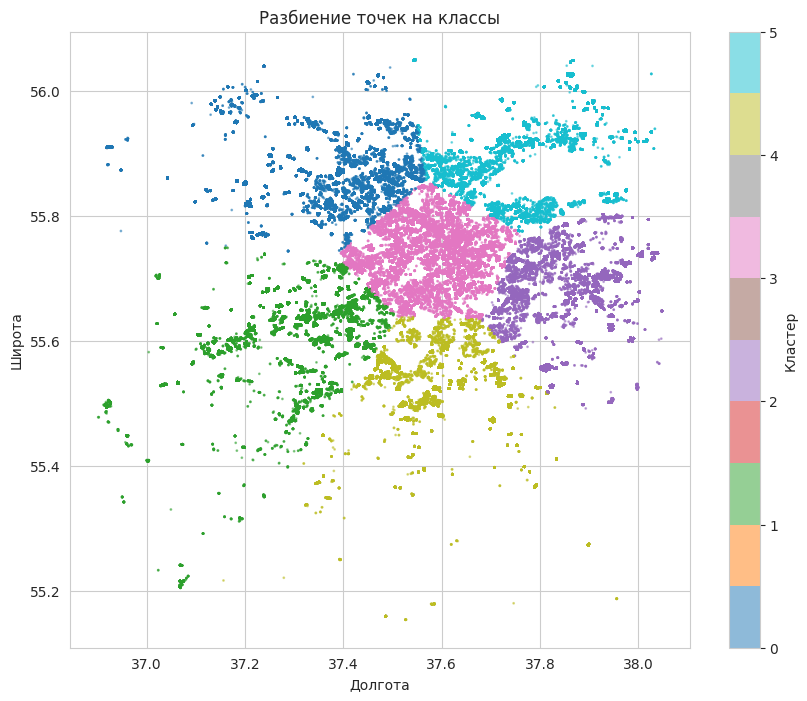

In [5]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_clean["longitude"],
    df_clean["latitude"],
    c=df_clean["cluster_zone"],
    cmap="tab10",
    s=1,
    alpha=0.5,
)
plt.colorbar(scatter, label="Кластер")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title("Разбиение точек на классы")
plt.show()

In [6]:
# Создаём столбец и заполняем его значением по умолчанию
df["cluster_zone"] = -1

# Заполняем метками для тех строк, которые были в df_clean
df.loc[df_clean.index, "cluster_zone"] = df_clean["cluster_zone"]

# Проверяем, сколько объектов осталось без кластера
print(
    f"Объектов без кластера (из‑за пропусков координат): {(df['cluster_zone'] == -1).sum()}"
)

if "cluster_zone" not in df.columns:
    df_clean = df.dropna(subset=["longitude", "latitude"]).copy()
    coords = df_clean[["longitude", "latitude"]].values
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

    kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
    clusters = kmeans.fit_predict(coords_scaled)
    df_clean["cluster_zone"] = clusters

    df["cluster_zone"] = -1
    df.loc[df_clean.index, "cluster_zone"] = df_clean["cluster_zone"]

Объектов без кластера (из‑за пропусков координат): 0


In [7]:
def plot_group_distribution(group_data, group_name, min_samples=10):
    area_vals = group_data["area"].dropna()
    floor_vals = group_data["floor"].dropna()
    n_area = len(area_vals)
    n_floor = len(floor_vals)

    # Если данных нет ни для одного признака – пропускаем группу
    if n_area < min_samples and n_floor < min_samples:
        print(
            f"Пропущена группа {group_name}: недостаточно данных (area: {n_area}, floor: {n_floor})"
        )
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Группа: {group_name}", fontsize=14)

    # --- area hist ---
    if n_area >= min_samples:
        sns.histplot(area_vals, kde=True, ax=axes[0, 0], stat="density", bins=30)
        axes[0, 0].set_title(f"area (n={n_area})")
        axes[0, 0].set_xlabel("area")
    else:
        axes[0, 0].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[0, 0].set_title("area")

    # --- area ecdf ---
    if n_area >= min_samples:
        sorted_vals = np.sort(area_vals)
        y = np.arange(1, n_area + 1) / n_area
        axes[0, 1].step(sorted_vals, y, where="post")
        axes[0, 1].set_title(f"ЭФР area (n={n_area})")
        axes[0, 1].set_xlabel("area")
        axes[0, 1].set_ylabel("Доля")
    else:
        axes[0, 1].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[0, 1].set_title("ЭФР area")

    # --- floor hist ---
    if n_floor >= min_samples:
        sns.histplot(floor_vals, kde=True, ax=axes[1, 0], stat="density", bins=30)
        axes[1, 0].set_title(f"floor (n={n_floor})")
        axes[1, 0].set_xlabel("floor")
    else:
        axes[1, 0].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[1, 0].set_title("floor")

    # --- floor ecdf ---
    if n_floor >= min_samples:
        sorted_vals = np.sort(floor_vals)
        y = np.arange(1, n_floor + 1) / n_floor
        axes[1, 1].step(sorted_vals, y, where="post")
        axes[1, 1].set_title(f"ЭФР floor (n={n_floor})")
        axes[1, 1].set_xlabel("floor")
        axes[1, 1].set_ylabel("Доля")
    else:
        axes[1, 1].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[1, 1].set_title("ЭФР floor")

    plt.tight_layout()
    plt.show()

In [8]:
def compare_primary_secondary(primary_df, secondary_df, min_samples=10):
    area_prim = primary_df["area"].dropna()
    area_sec = secondary_df["area"].dropna()
    floor_prim = primary_df["floor"].dropna()
    floor_sec = secondary_df["floor"].dropna()

    n_area_prim = len(area_prim)
    n_area_sec = len(area_sec)
    n_floor_prim = len(floor_prim)
    n_floor_sec = len(floor_sec)

    if (n_area_prim < min_samples and n_area_sec < min_samples) and (
        n_floor_prim < min_samples and n_floor_sec < min_samples
    ):
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Наложение первички и вторички", fontsize=16)

    # ------------------ Гистограмма площади (area) ------------------
    ax = axes[0, 0]
    ax.set_title("Гистограмма площади (area)")
    ax.set_xlabel("Площадь, м²")
    ax.set_ylabel("Плотность")
    if n_area_prim >= min_samples:
        sns.histplot(
            area_prim,
            kde=True,
            stat="density",
            bins=30,
            color="blue",
            alpha=0.5,
            label=f"primary (n={n_area_prim})",
            ax=ax,
        )
    if n_area_sec >= min_samples:
        sns.histplot(
            area_sec,
            kde=True,
            stat="density",
            bins=30,
            color="orange",
            alpha=0.5,
            label=f"secondary (n={n_area_sec})",
            ax=ax,
        )
    if n_area_prim < min_samples and n_area_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ ЭФР площади ------------------
    ax = axes[0, 1]
    ax.set_title("ЭФР площади")
    ax.set_xlabel("Площадь, м²")
    ax.set_ylabel("Доля")
    if n_area_prim >= min_samples:
        sorted_vals = np.sort(area_prim)
        y = np.arange(1, n_area_prim + 1) / n_area_prim
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="blue",
            label=f"primary (n={n_area_prim})",
        )
    if n_area_sec >= min_samples:
        sorted_vals = np.sort(area_sec)
        y = np.arange(1, n_area_sec + 1) / n_area_sec
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="orange",
            label=f"secondary (n={n_area_sec})",
        )
    if n_area_prim < min_samples and n_area_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ Гистограмма этажа (floor) ------------------
    ax = axes[1, 0]
    ax.set_title("Гистрограмма этажа (floor)")
    ax.set_xlabel("Этаж")
    ax.set_ylabel("Плотность")
    if n_floor_prim >= min_samples:
        sns.histplot(
            floor_prim,
            kde=True,
            stat="density",
            bins=30,
            color="blue",
            alpha=0.5,
            label=f"primary (n={n_floor_prim})",
            ax=ax,
        )
    if n_floor_sec >= min_samples:
        sns.histplot(
            floor_sec,
            kde=True,
            stat="density",
            bins=30,
            color="orange",
            alpha=0.5,
            label=f"secondary (n={n_floor_sec})",
            ax=ax,
        )
    if n_floor_prim < min_samples and n_floor_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ ЭФР этажа ------------------
    ax = axes[1, 1]
    ax.set_title("ЭФР этажа")
    ax.set_xlabel("Этаж")
    ax.set_ylabel("Доля")
    if n_floor_prim >= min_samples:
        sorted_vals = np.sort(floor_prim)
        y = np.arange(1, n_floor_prim + 1) / n_floor_prim
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="blue",
            label=f"primary (n={n_floor_prim})",
        )
    if n_floor_sec >= min_samples:
        sorted_vals = np.sort(floor_sec)
        y = np.arange(1, n_floor_sec + 1) / n_floor_sec
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="orange",
            label=f"secondary (n={n_floor_sec})",
        )
    if n_floor_prim < min_samples and n_floor_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    plt.tight_layout()
    plt.show()

Графики ЭФР для первички и вторички с наложением:

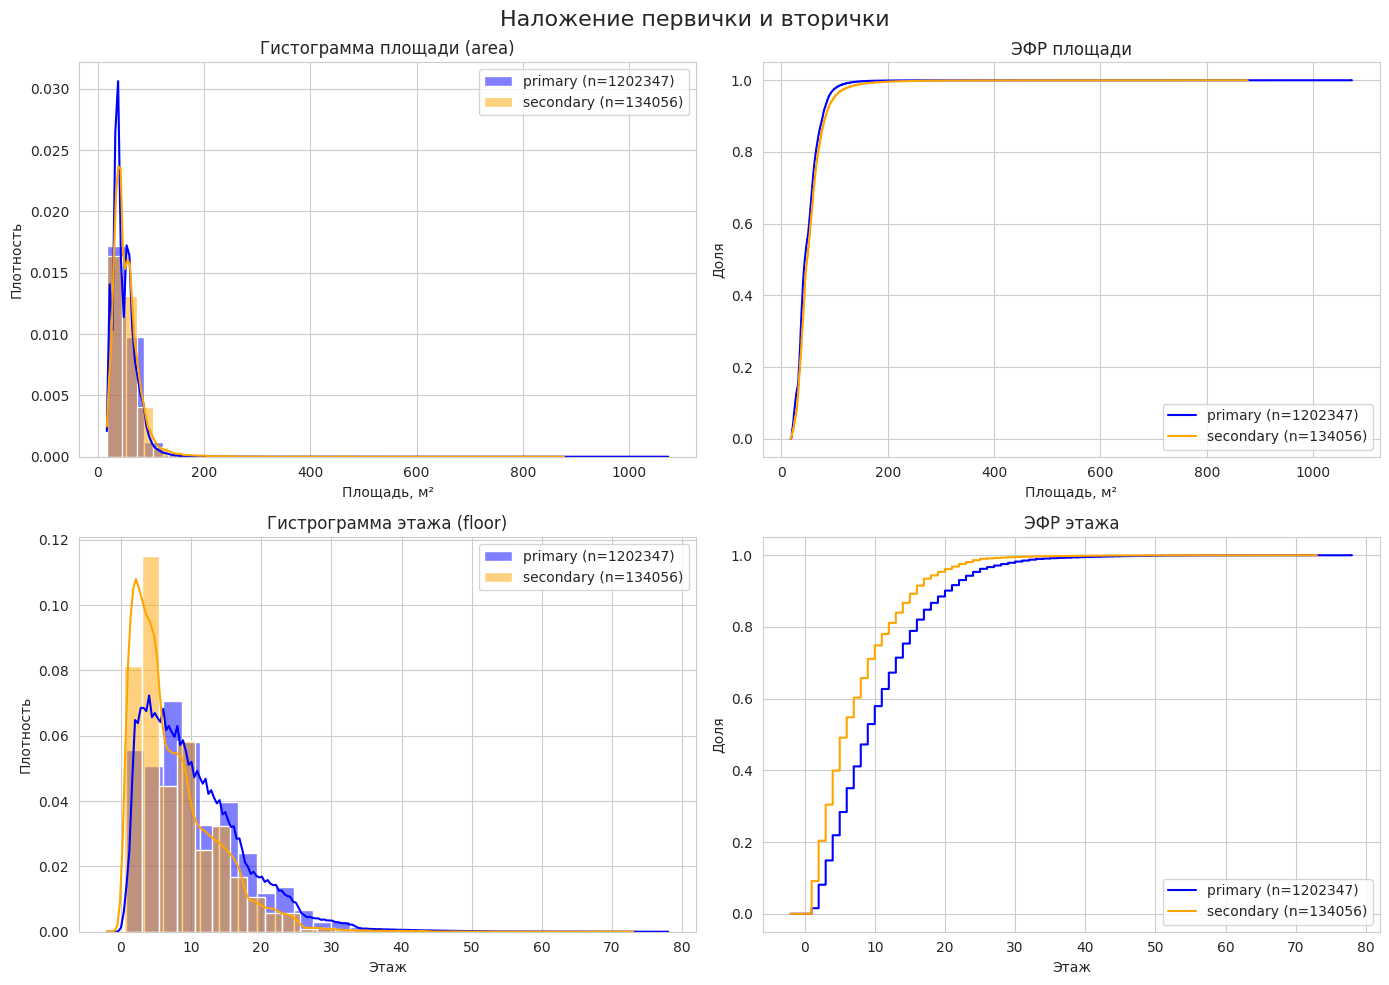

In [9]:
primary = df[df["market_type"] == "primary"]
secondary = df[df["market_type"] == "secondary"]
compare_primary_secondary(primary, secondary)

Параметры, по которым будем проводить группировки:

In [10]:
features = ["area", "floor"]

groupings = {
    "overall": None,
    "by_flat_type": "flat_type",
    "by_zone": "cluster_zone",
}

ЭФР по группам:

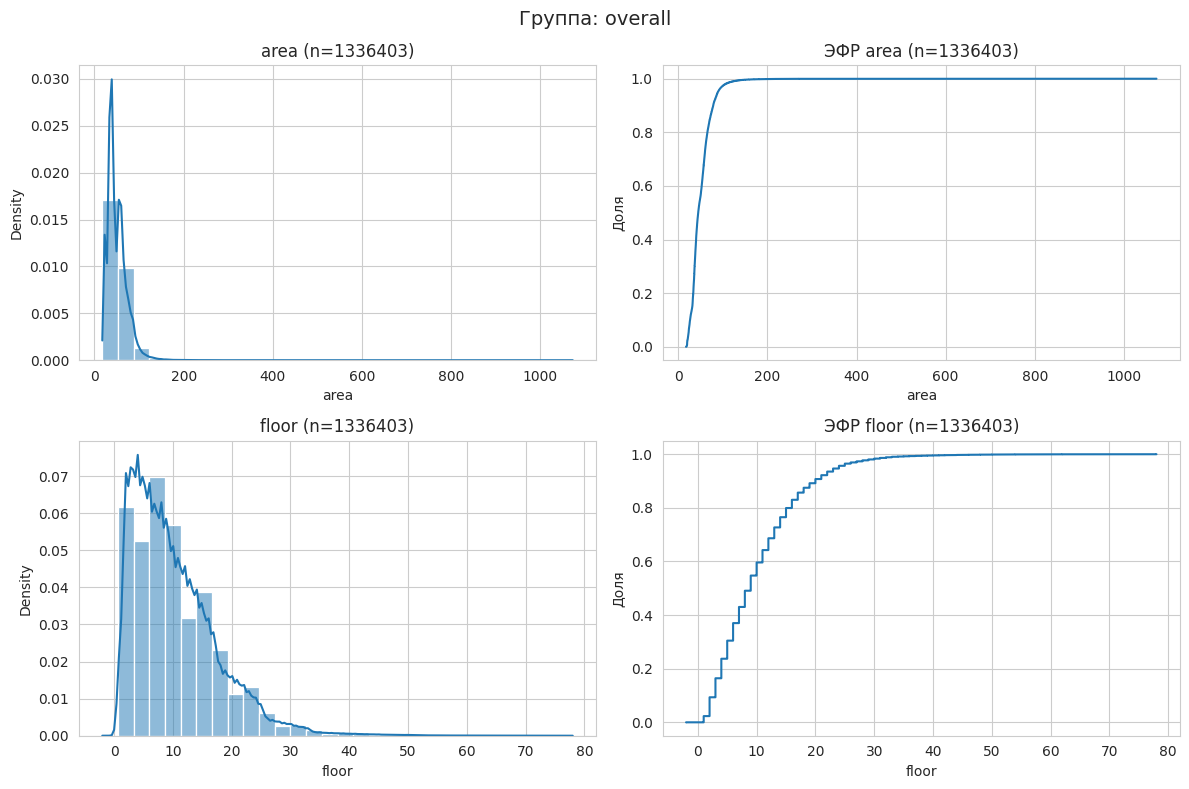

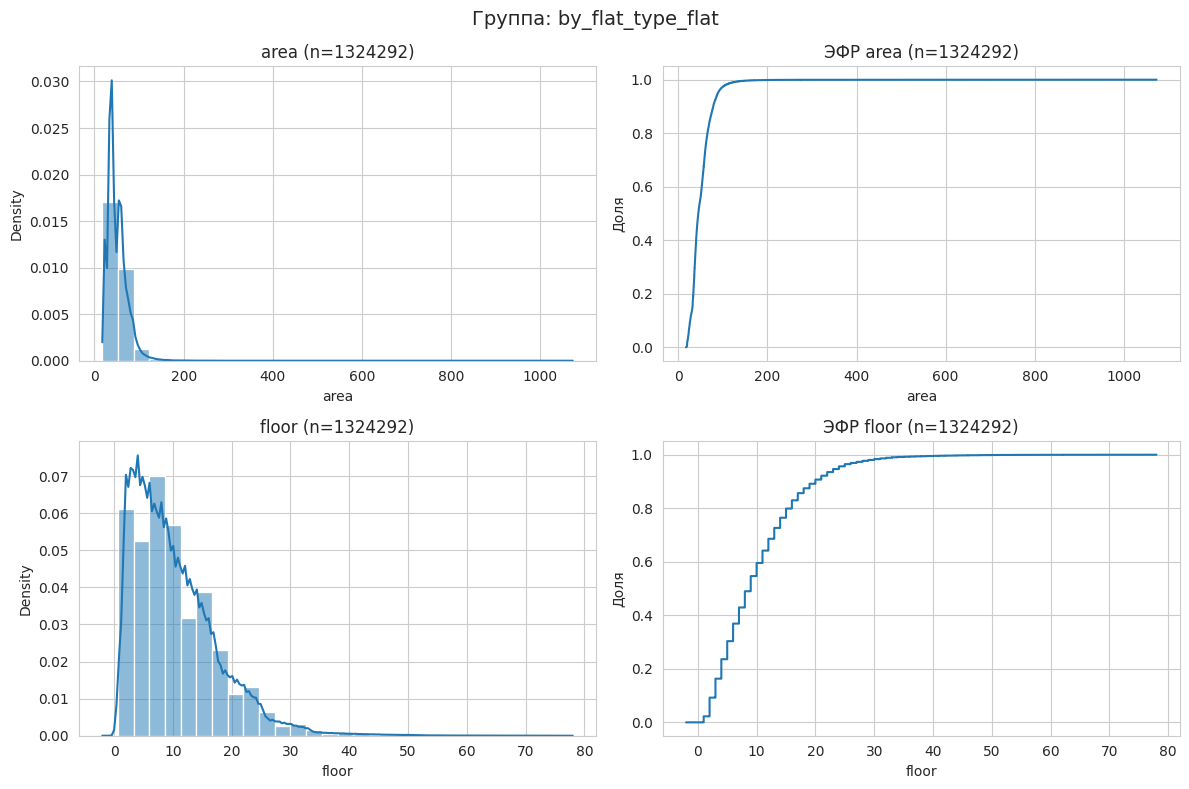

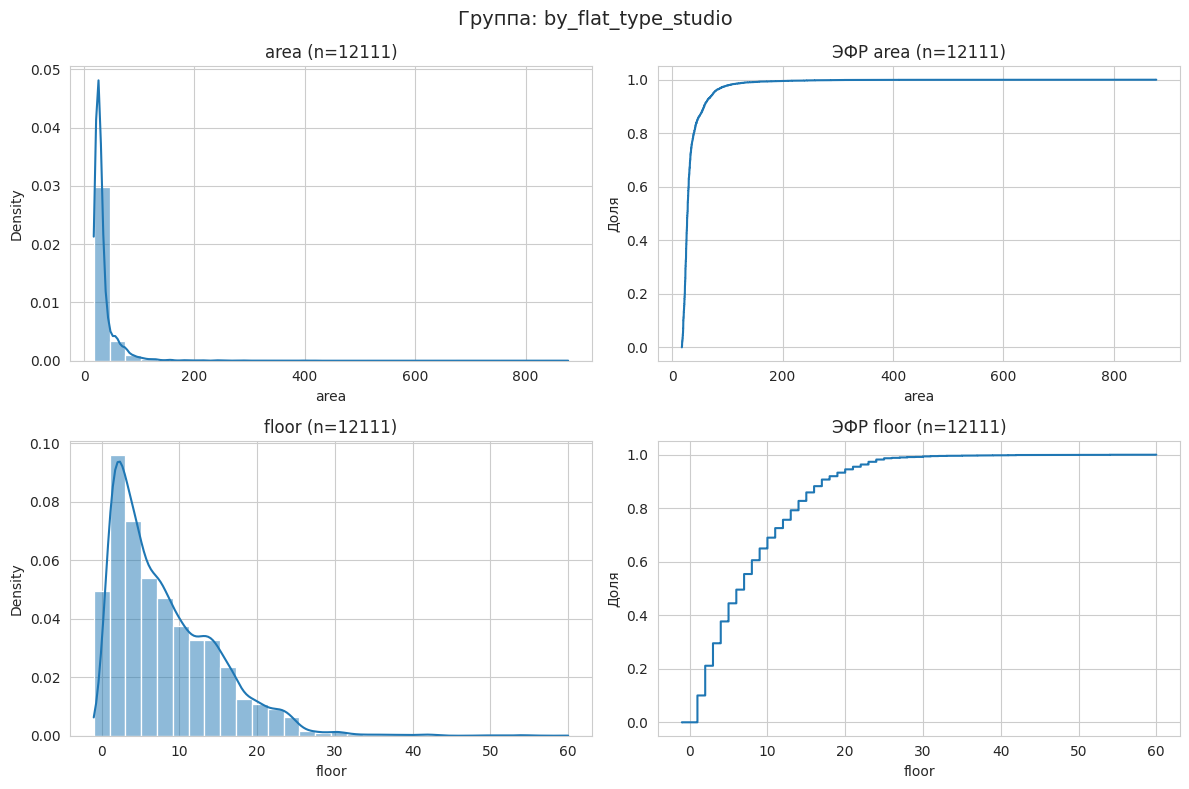

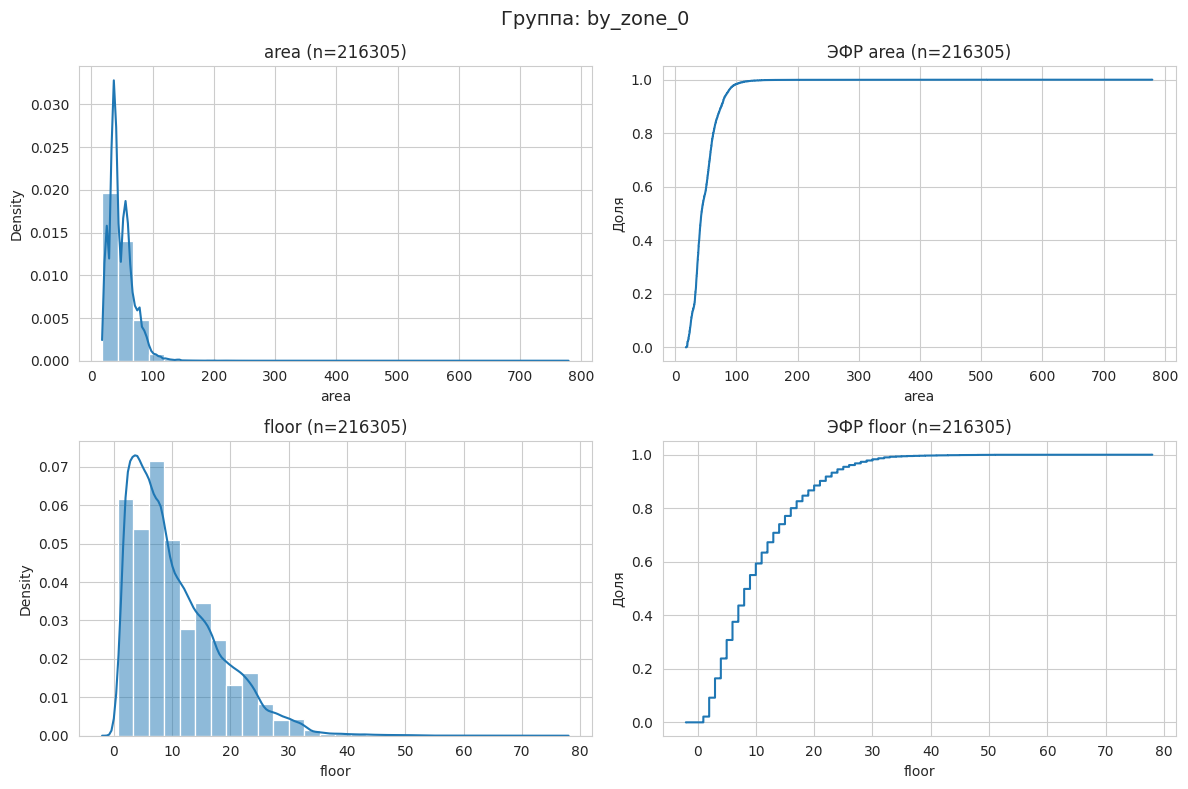

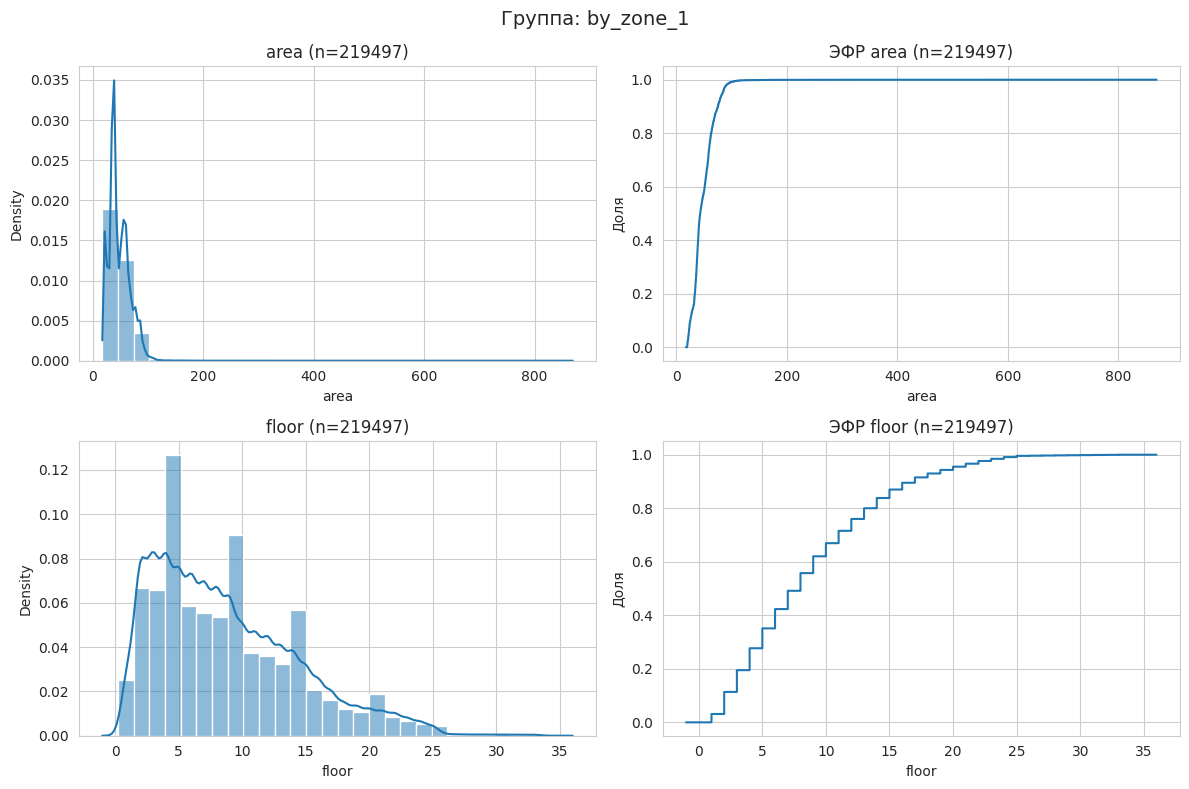

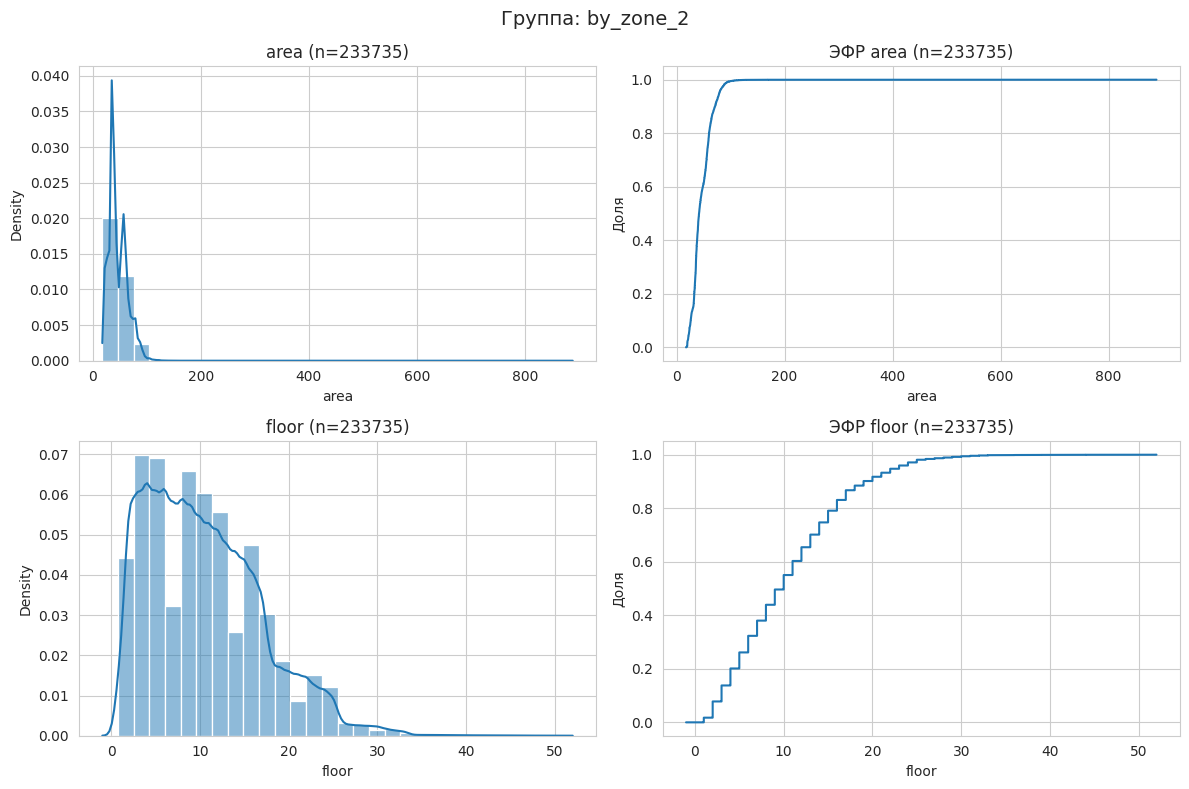

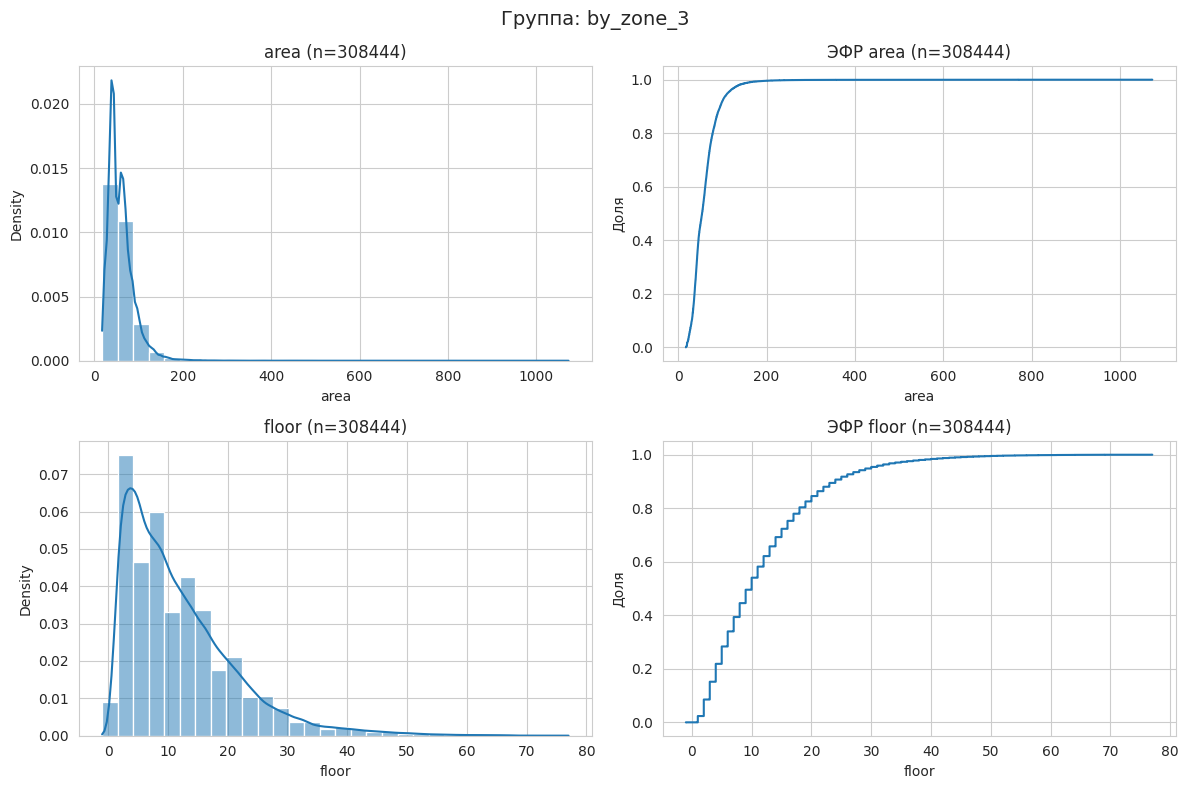

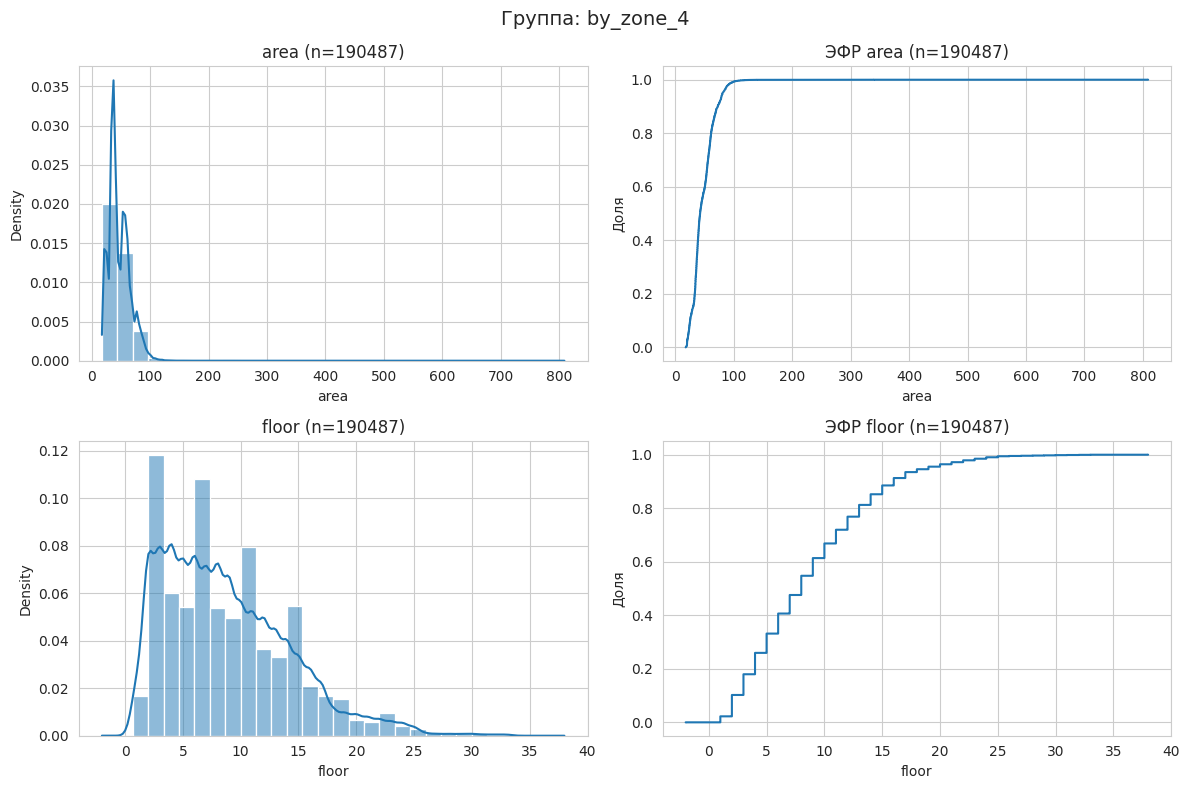

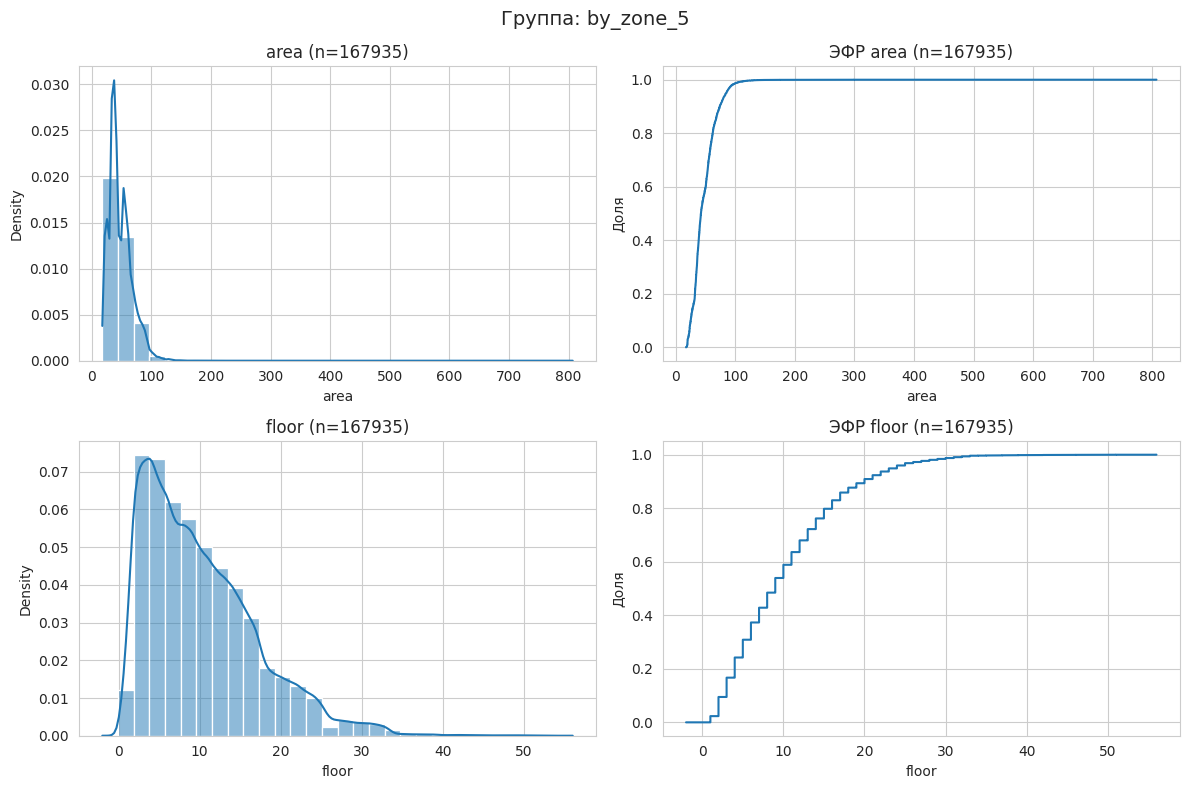

In [11]:
total_groups = 0

for group_name, group_col in groupings.items():
    if group_col is None:
        plot_group_distribution(df, group_name)
        total_groups += 1
    else:
        if isinstance(group_col, list):
            grouped = df.groupby(group_col)
            for keys, sub_df in grouped:
                keys_str = "_".join(str(k) for k in keys)
                sub_group_name = f"{group_name}_{keys_str}"
                plot_group_distribution(sub_df, sub_group_name)
                total_groups += 1
        else:
            grouped = df.groupby(group_col)
            for key, sub_df in grouped:
                sub_group_name = f"{group_name}_{key}"
                plot_group_distribution(sub_df, sub_group_name)
                total_groups += 1

Графики ЭФР и плотности представлены в ячейке выше.